In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [4]:
df = df.drop(['Unnamed: 15', 'Unnamed: 16'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [5]:
df_new = df.copy()

In [6]:
df_new = df[df['T'] != -200]
df_new = df_new.dropna()
df_new = df_new.reset_index(drop=True)

In [7]:
df_new['CO(GT)'] = df_new['CO(GT)'].replace(-200, df_new['CO(GT)'].median()).fillna(df_new['CO(GT)'].median())
df_new['NOx(GT)'] = df_new['NOx(GT)'].replace(-200, df_new['NOx(GT)'].median()).fillna(df_new['NOx(GT)'].median())
df_new['NO2(GT)'] = df_new['NO2(GT)'].replace(-200, df_new['NO2(GT)'].median()).fillna(df_new['NO2(GT)'].median())

In [8]:
df_new = df_new.drop('NMHC(GT)', axis=1)

In [9]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           8991 non-null   object 
 1   Time           8991 non-null   object 
 2   CO(GT)         8991 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   C6H6(GT)       8991 non-null   float64
 5   PT08.S2(NMHC)  8991 non-null   float64
 6   NOx(GT)        8991 non-null   float64
 7   PT08.S3(NOx)   8991 non-null   float64
 8   NO2(GT)        8991 non-null   float64
 9   PT08.S4(NO2)   8991 non-null   float64
 10  PT08.S5(O3)    8991 non-null   float64
 11  T              8991 non-null   float64
 12  RH             8991 non-null   float64
 13  AH             8991 non-null   float64
dtypes: float64(12), object(2)
memory usage: 983.5+ KB


In [10]:
df_new['Date'] = pd.to_datetime(df_new['Date'], format='%d/%m/%Y')
df_new['Date']

0      2004-03-10
1      2004-03-10
2      2004-03-10
3      2004-03-10
4      2004-03-10
          ...    
8986   2005-04-04
8987   2005-04-04
8988   2005-04-04
8989   2005-04-04
8990   2005-04-04
Name: Date, Length: 8991, dtype: datetime64[ns]

In [11]:
df_new['Month'] = df_new['Date'].dt.month
df_new['Day_of_week'] = df_new['Date'].dt.dayofweek
df_new['Year'] = df_new['Date'].dt.year

In [12]:
df_new = df_new.drop('Date', axis=1)

In [13]:
df_new['Time'] = pd.to_datetime(df_new['Time'], format='%H.%M.%S').dt.time
df_new['Hour'] = pd.to_datetime(df_new['Time'], format='%H:%M:%S').dt.hour

In [14]:
df_new = df_new.drop('Time', axis=1)

In [15]:
df_new.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month,Day_of_week,Year,Hour
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.014359,1099.833166,10.083105,939.153376,224.060950,835.493605,109.275609,1456.264598,1022.906128,18.317829,49.234201,1.025530,6.327772,3.015237,2004.234568,11.479591
std,1.320893,217.080037,7.449820,266.831429,191.146299,256.817320,43.627915,346.206794,398.484288,8.832116,17.316892,0.403813,3.407854,2.014599,0.423752,6.913320
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,1.000000,0.000000,2004.000000,0.000000
25%,1.200000,937.000000,4.400000,734.500000,112.000000,658.000000,85.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,3.000000,1.000000,2004.000000,5.000000
50%,1.500000,1063.000000,8.200000,909.000000,140.000000,806.000000,96.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,6.000000,3.000000,2004.000000,11.000000
75%,2.600000,1231.000000,14.000000,1116.000000,280.000000,969.500000,132.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,9.000000,5.000000,2004.000000,17.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,333.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,12.000000,6.000000,2005.000000,23.000000


In [16]:
X = df_new.drop(['T', 'RH', 'AH'], axis=1)
y = df_new[['T', 'RH', 'AH']]

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         8991 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   C6H6(GT)       8991 non-null   float64
 3   PT08.S2(NMHC)  8991 non-null   float64
 4   NOx(GT)        8991 non-null   float64
 5   PT08.S3(NOx)   8991 non-null   float64
 6   NO2(GT)        8991 non-null   float64
 7   PT08.S4(NO2)   8991 non-null   float64
 8   PT08.S5(O3)    8991 non-null   float64
 9   Month          8991 non-null   int32  
 10  Day_of_week    8991 non-null   int32  
 11  Year           8991 non-null   int32  
 12  Hour           8991 non-null   int32  
dtypes: float64(9), int32(4)
memory usage: 772.8 KB


In [18]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       8991 non-null   float64
 1   RH      8991 non-null   float64
 2   AH      8991 non-null   float64
dtypes: float64(3)
memory usage: 210.9 KB


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7192, 13), (1799, 13), (7192, 3), (1799, 3))

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

In [23]:
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

In [24]:
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [25]:
tf.random.set_seed(25)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=5)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, name='output')
])

model.compile(
    loss=tf.keras.losses.mse,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

history = model.fit(X_train_scaled, y_train_scaled, validation_split=0.1, callbacks=callback, epochs=500)

Epoch 1/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5239 - mae: 0.5605 - val_loss: 0.2834 - val_mae: 0.4076
Epoch 2/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2502 - mae: 0.3705 - val_loss: 0.1981 - val_mae: 0.3298
Epoch 3/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1981 - mae: 0.3264 - val_loss: 0.1668 - val_mae: 0.3023
Epoch 4/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1714 - mae: 0.3045 - val_loss: 0.1477 - val_mae: 0.2853
Epoch 5/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1550 - mae: 0.2902 - val_loss: 0.1330 - val_mae: 0.2718
Epoch 6/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1430 - mae: 0.2788 - val_loss: 0.1220 - val_mae: 0.2606
Epoch 7/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1341 - mae: 0.2697 - val_loss: 0.1142 - val_mae: 0.2524
Epoch 8/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1274 - mae: 0.2627 - val_loss: 0.1085 - val_mae: 0.2458
Epoch 9/500
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,227 (36.05 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,152 (24.04 KB)

In [27]:
y_pred_scaled = model.predict(X_test_scaled)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [28]:
y_pred_scaled

array([[-0.9527265 ,  0.51256734, -0.85911024],
       [-1.0578426 ,  0.809004  , -0.7050456 ],
       [ 0.17811152,  1.3310289 ,  1.7035797 ],
       ...,
       [ 2.0247254 , -1.7822623 ,  0.19354832],
       [-0.20664501,  0.3598128 , -0.04052424],
       [-0.26200125,  1.3319459 ,  0.66036516]],
      shape=(1799, 3), dtype=float32)

In [29]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)

In [30]:
y_pred_df = pd.DataFrame(y_pred, columns=['T', 'RH', 'AH'])

In [31]:
y_test.head()

,T,RH,AH
393,7.9,63.5,0.6777
8379,6.1,72.1,0.6847
4996,19.4,70.4,1.5663
1111,14.7,49.9,0.8280
518,11.9,60.9,0.8455


In [32]:
y_pred_df.head()

,T,RH,AH
0,9.983937,58.059063,0.682588
1,9.051687,63.214516,0.744692
2,20.013069,72.293274,1.715614
3,13.117500,52.777172,0.825652
4,14.465651,57.324368,0.912114


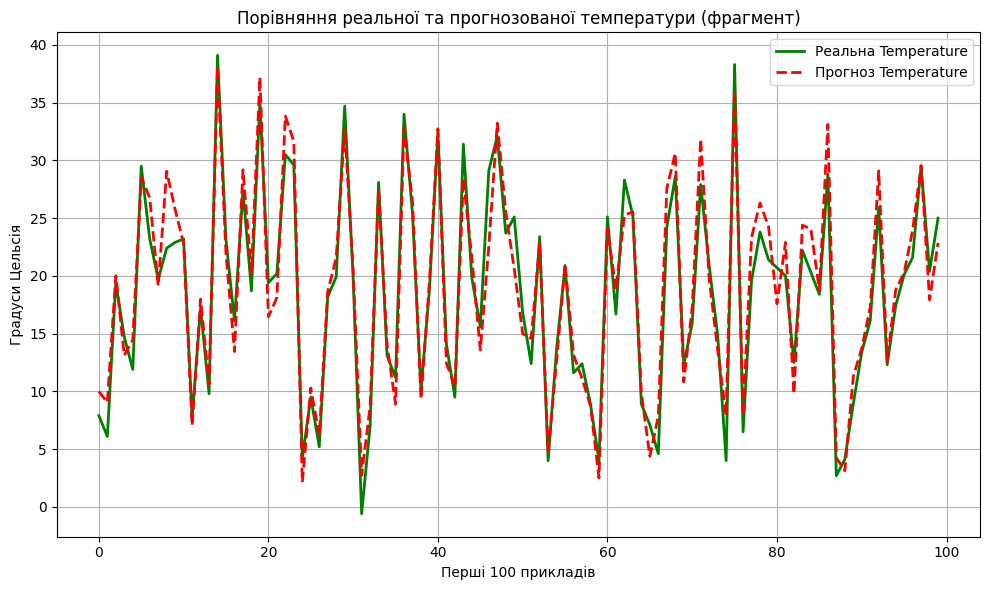

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(y_test['T'].values[:100], label='Реальна Temperature', color='green', linewidth=2)
plt.plot(y_pred_df['T'].values[:100], label='Прогноз Temperature', color='red', linestyle='--', linewidth=2)

plt.title('Порівняння реальної та прогнозованої температури (фрагмент)')
plt.xlabel('Перші 100 прикладів')
plt.ylabel('Градуси Цельсія')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

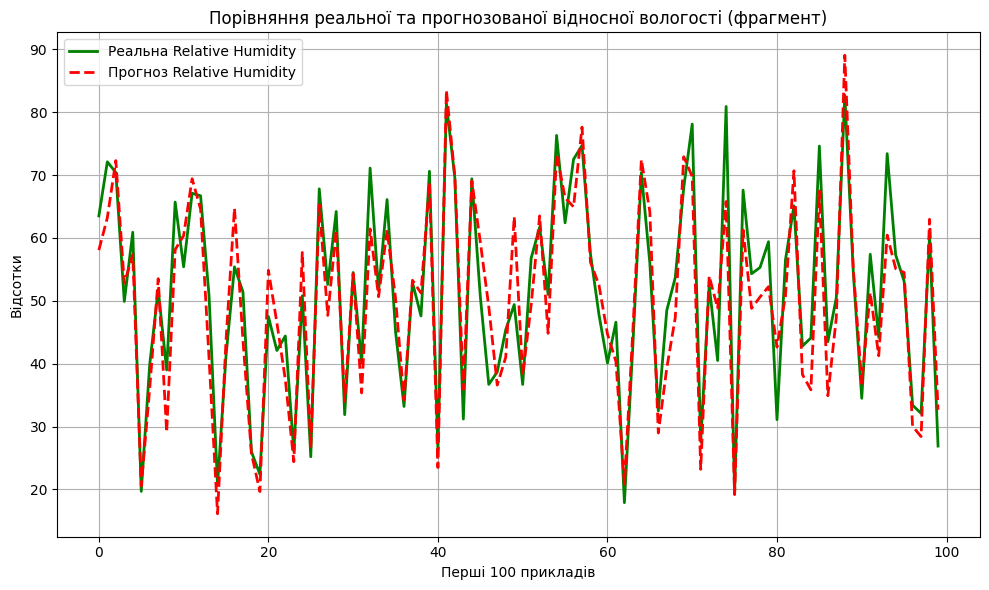

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(y_test['RH'].values[:100], label='Реальна Relative Humidity', color='green', linewidth=2)
plt.plot(y_pred_df['RH'].values[:100], label='Прогноз Relative Humidity', color='red', linestyle='--', linewidth=2)

plt.title('Порівняння реальної та прогнозованої відносної вологості (фрагмент)')
plt.xlabel('Перші 100 прикладів')
plt.ylabel('Відсотки')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

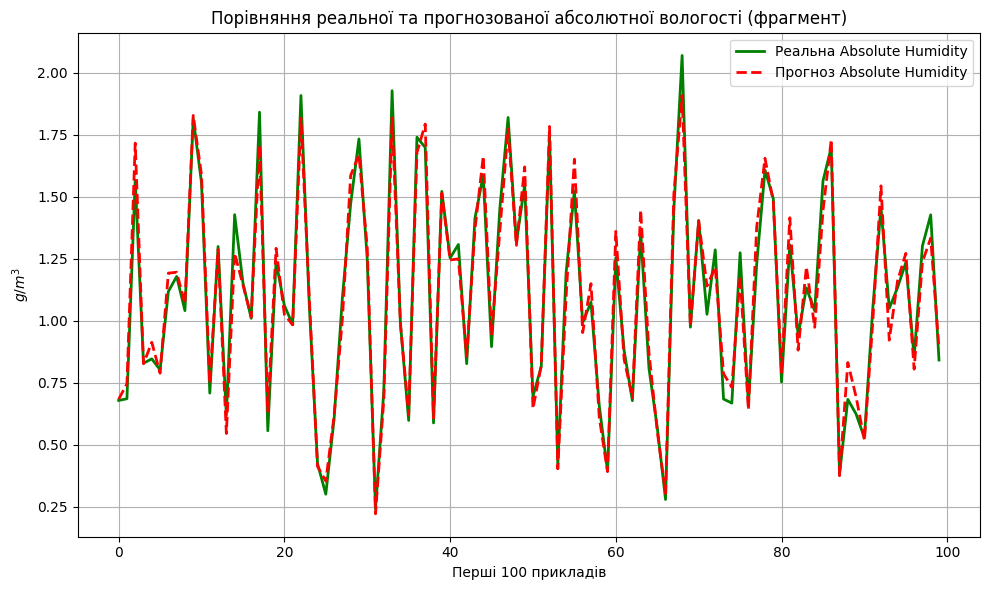

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(y_test['AH'].values[:100], label='Реальна Absolute Humidity', color='green', linewidth=2)
plt.plot(y_pred_df['AH'].values[:100], label='Прогноз Absolute Humidity', color='red', linestyle='--', linewidth=2)

plt.title('Порівняння реальної та прогнозованої абсолютної вологості (фрагмент)')
plt.xlabel('Перші 100 прикладів')
plt.ylabel('$g/m^3$')
plt.grid(True)

plt.tight_layout()
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error

In [37]:
mae_t = mean_absolute_error(y_test['T'], y_pred_df['T'])
mae_rh = mean_absolute_error(y_test['RH'], y_pred_df['RH'])
mae_ah = mean_absolute_error(y_test['AH'], y_pred_df['AH'])

print(f'MAE Temperature: {mae_t:.2f}'
      f'\nMAE Relative Humidity: {mae_rh:.2f}'
      f'\nMAE Absolute Humidity: {mae_ah:.2f}')

MAE Temperature: 1.89
MAE Relative Humidity: 5.22
MAE Absolute Humidity: 0.05


In [38]:
y_test.describe()

,T,RH,AH
count,1799.000000,1799.000000,1799.000000
mean,17.855642,49.591662,1.012070
std,8.668590,17.010805,0.406363
min,-1.900000,9.900000,0.186200
25%,11.400000,36.400000,0.722300
50%,17.400000,50.000000,0.980100
75%,23.700000,62.550000,1.293450
max,44.600000,87.200000,2.231000


Маємо стандартне відхилення по температурі 8.66, а модель визначає з точністю 1.89.  
Стандартне відхилення по відносній вологості 17%, модель визначає з точністю до 5%.  
По абсолютній вологості - 0.4, модель визначає з точністю 0.05.  
Дуже гарні показники.  

In [1]:
!nvidia-smi

Fri Feb 27 20:48:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P0             12W /   61W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----